## **1 - ĐÁNH GIÁ RECALL@K TRÊN FASHIONIQ**

Notebook chỉ sử dụng các vector đã lưu để:

```text
candidate image embedding
        +
relative caption embedding
        ↓
additive query embedding
        ↓
so sánh với gallery ảnh
        ↓
xếp hạng theo similarity
        ↓
kiểm tra target ground-truth
        ↓
Recall@10 và Recall@50
```

Quá trình đánh giá sử dụng tập dữ liệu kiểm định (validation split) vì tập này đã có sẵn đáp án (target) để tự động chấm điểm. Hệ thống sẽ chạy kiểm tra trên 3 loại trang phục: Dress, Shirt và Toptee. Kết quả cuối cùng sẽ báo cáo các chỉ số Recall@10 và Recall@50 cho từng loại đồ, kèm theo điểm trung bình chung (Macro Average và Micro Overall). Toàn bộ chi tiết của từng câu truy vấn cũng được tự động xuất ra file riêng để dễ dàng kiểm tra lại khi cần.


## **2 - KIỂM TRA MÔI TRƯỜNG LOCAL**

Cell này kiểm tra Python, hệ điều hành và số luồng CPU.


In [2]:
import sys
import os
import platform
import numpy as np
import pandas as pd

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("NumPy", np.__version__)
print("Pandas", pd.__version__)
print("CPU threads", os.cpu_count())

Python 3.11.9
Platform Windows-10-10.0.26200-SP0
NumPy 2.4.6
Pandas 3.0.6
CPU threads 12


## **3 - CÀI THƯ VIỆN NẾU MÁY THIẾU**

Chỉ chạy cell dưới nếu import thư viện bị lỗi.

- `numpy`: tính vector và similarity.
- `pandas`: xử lý metadata và lưu kết quả.
- `tqdm`: hiển thị tiến trình.
- `matplotlib`, `Pillow`: hiển thị một số kết quả retrieval mẫu.

Bỏ qua cell 3 nếu thư viện đã được import ở cell 2.


In [2]:
%pip install --upgrade numpy pandas tqdm matplotlib pillow

print("Đã cài xong")

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.9 MB 8.4 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.9 MB 9.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 9.6 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.9 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 9.6 MB/s  0:00:01
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.5
    Uninstalling pandas-3.0.5:
      Successfully uninstalled pandas-3.0.5
Note: you may need to restart the kernel to use updated packages.
Đã cài xong


  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Nguyen Ho Vinh  Hien\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## **4 - CẤU TRÚC THƯ MỤC LOCAL**


```text
C:\Users\Nguyen Ho Vinh  Hien\Downloads\FashionIQ\fashionIQ_dataset
├── captions
├── images
└── image_splits
```

Embedding tuần 37:

```text
C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings
├── fashionclip_text_embeddings.npy
├── fashionclip_text_metadata.csv
├── fashionclip_image_embeddings.npy
└── fashionclip_image_ids.csv
```

Output tuần 38:

```text
C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week38\evaluation
```


## **5 - CONFIG**

Đây là cell cấu hình chính cần chạy lại cell này sau mỗi lần Restart Kernel.

Các tham số quan trọng:
- `QUERY_BATCH_SIZE`: số query được tính similarity cùng lúc.
- `TOP_KS`: các mốc Recall cần tính.
- `EXCLUDE_REFERENCE`: loại candidate/reference image khỏi ranking để tránh hệ thống trả lại chính ảnh tham chiếu.


In [3]:
from pathlib import Path

WORK_ROOT = Path(r"C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week38")
DATA_ROOT = Path(r"C:\Users\Nguyen Ho Vinh  Hien\Downloads\FashionIQ\fashionIQ_dataset")
WEEK37_EMB_ROOT = Path(r"C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings")

OUTPUT_ROOT = WORK_ROOT / "evaluation"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CAPTIONS_DIR = DATA_ROOT / "captions"
IMAGES_DIR = DATA_ROOT / "images"
SPLITS_DIR = DATA_ROOT / "image_splits"

FCLIP_TEXT_EMB_FILE = WEEK37_EMB_ROOT / "fashionclip_text_embeddings.npy"
FCLIP_TEXT_META_FILE = WEEK37_EMB_ROOT / "fashionclip_text_metadata.csv"

FCLIP_IMAGE_EMB_FILE = WEEK37_EMB_ROOT / "fashionclip_image_embeddings.npy"
FCLIP_IMAGE_MAP_FILE = WEEK37_EMB_ROOT / "fashionclip_image_ids.csv"

CATEGORIES = ["dress", "shirt", "toptee"]
EVAL_SPLIT = "val"

TOP_KS = [10, 50]
QUERY_BATCH_SIZE = 128
EXCLUDE_REFERENCE = True

print("WORK_ROOT ", WORK_ROOT)
print("DATA_ROOT ", DATA_ROOT)
print("WEEK37_EMB_ROOT ", WEEK37_EMB_ROOT)
print("OUTPUT_ROOT ", OUTPUT_ROOT)
print("TOP_KS ", TOP_KS)
print("QUERY_BATCH_SIZE ", QUERY_BATCH_SIZE)
print("EXCLUDE_REFERENCE ", EXCLUDE_REFERENCE)

WORK_ROOT  C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week38
DATA_ROOT  C:\Users\Nguyen Ho Vinh  Hien\Downloads\FashionIQ\fashionIQ_dataset
WEEK37_EMB_ROOT  C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings
OUTPUT_ROOT  C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week38\evaluation
TOP_KS  [10, 50]
QUERY_BATCH_SIZE  128
EXCLUDE_REFERENCE  True


## **6 - KIỂM TRA FILE ĐẦU VÀO TỪ TUẦN 37**

Cell này xác nhận bốn file quan trọng từ tuần trước còn tồn tại.

Nếu một file báo `False` cần dừng notebook và kiểm tra lại đường dẫn ở Cell 5.

- Text embedding dùng để biểu diễn relative caption.
- Image embedding dùng cho candidate và gallery.
- Metadata/mapping dùng để biết mỗi vector thuộc sample hay image ID nào.


In [4]:
required_files = [
    FCLIP_TEXT_EMB_FILE,
    FCLIP_TEXT_META_FILE,
    FCLIP_IMAGE_EMB_FILE,
    FCLIP_IMAGE_MAP_FILE,
]

all_ok = True

for p in required_files:
    ok = p.exists()
    print(p.name, "->", ok)
    all_ok = all_ok and ok

if not all_ok:
    raise FileNotFoundError(
        "Thiếu file embedding hoặc mapping tuần 37. "
        "Kiểm tra lại WEEK37_EMB_ROOT trong Cell 5."
    )

print("\nTất cả file đầu vào đã sẵn sàng")

fashionclip_text_embeddings.npy -> True
fashionclip_text_metadata.csv -> True
fashionclip_image_embeddings.npy -> True
fashionclip_image_ids.csv -> True

Tất cả file đầu vào đã sẵn sàng


## **7 - LOAD EMBEDDING VÀ MAPPING**

Cell này nạp các vector đã tạo tuần trước. `mmap_mode="r"` được dùng cho file NumPy lớn để giảm lượng RAM cần nạp ngay lập tức.


In [5]:
import numpy as np
import pandas as pd

text_embeddings = np.load(
    FCLIP_TEXT_EMB_FILE,
    mmap_mode="r"
)

text_metadata = pd.read_csv(
    FCLIP_TEXT_META_FILE,
    dtype=str
)

image_embeddings = np.load(
    FCLIP_IMAGE_EMB_FILE,
    mmap_mode="r"
)

image_map = pd.read_csv(
    FCLIP_IMAGE_MAP_FILE,
    dtype={"image_id": str, "image_path": str}
)

print("Text embeddings shape ", text_embeddings.shape)
print("Text metadata rows ", len(text_metadata))
print("Image embeddings shape ", image_embeddings.shape)
print("Image mapping rows ", len(image_map))

assert text_embeddings.shape[0] == len(text_metadata)
assert image_embeddings.shape[0] == len(image_map)
assert text_embeddings.shape[1] == 512
assert image_embeddings.shape[1] == 512

print("\nLoad embedding và mapping thành công")

Text embeddings shape  (90402, 512)
Text metadata rows  90402
Image embeddings shape  (74381, 512)
Image mapping rows  74381

Load embedding và mapping thành công


## **8 - SANITY CHECK EMBEDDING TUẦN 37**

Trước khi tính toán chỉ số Recall@K, ma trận embedding sẽ được kiểm tra nhanh (sanity check) để đảm bảo dữ liệu hoàn toàn hợp lệ. Các điều kiện bắt buộc bao gồm: không chứa giá trị lỗi (NaN hay Inf) và độ dài vector (norm) trung bình xấp xỉ 1 (do đã được chuẩn hóa L2 từ trước). Chỉ khi thỏa mãn các tiêu chí này, các vector mới đủ tiêu chuẩn để đưa vào tính toán độ tương đồng (similarity).


In [6]:
def quick_check(name, arr):
    sample = np.asarray(arr[: min(5000, len(arr))], dtype=np.float32)

    nan_count = int(np.isnan(sample).sum())
    inf_count = int(np.isinf(sample).sum())
    norms = np.linalg.norm(sample, axis=1)

    print(name)
    print("Sample rows ", len(sample))
    print("NaN ", nan_count)
    print("Inf ", inf_count)
    print("Norm mean ", float(norms.mean()))
    print("Norm min ", float(norms.min()))
    print("Norm max ", float(norms.max()))

    assert nan_count == 0
    assert inf_count == 0

quick_check("FashionCLIP text", text_embeddings)
quick_check("FashionCLIP image", image_embeddings)

print("\nSANITY CHECK PASS")

FashionCLIP text
Sample rows  5000
NaN  0
Inf  0
Norm mean  1.0
Norm min  0.9999998211860657
Norm max  1.0000001192092896
FashionCLIP image
Sample rows  5000
NaN  0
Inf  0
Norm mean  1.0
Norm min  0.9999998211860657
Norm max  1.0000001192092896

SANITY CHECK PASS


## **9 - TẠO EVALUATION QUERY CHỈ TỪ CATEGORY-SPECIFIC VALIDATION FILES**

Rút kinh nghiệm từ sự cố trùng lặp dữ liệu ở tuần trước, giao thức đánh giá tuần này chỉ nạp đích danh 3 tệp theo phân loại là cap.dress.val.json, cap.shirt.val.json và cap.toptee.val.json. Việc khoanh vùng này giúp loại bỏ triệt để các mẫu thử bị đếm đúp.

Đồng thời, mỗi câu truy vấn (query) sẽ được chuẩn hóa với 4 thành phần cốt lõi:

- candidate: Ảnh gốc (tham chiếu).

- text: Câu mô tả yêu cầu chỉnh sửa.

- target: Đáp án đúng (ảnh cần tìm).

- text_embedding_row: Vị trí liên kết với ma trận text embedding đã lưu ở tuần 37.


In [7]:
eval_parts = []

for category in CATEGORIES:
    expected_file = f"cap.{category}.{EVAL_SPLIT}.json"

    mask = text_metadata["source_file"].eq(expected_file)
    part = text_metadata.loc[mask].copy()

    part["text_embedding_row"] = np.flatnonzero(mask.to_numpy())
    part["eval_category"] = category

    eval_parts.append(part)

eval_queries = pd.concat(eval_parts, ignore_index=True)

print("Tổng số query validation ", len(eval_queries))
print("\nSố query theo category")
print(eval_queries.groupby("eval_category").size())

print("\nMissing candidate ", eval_queries["candidate"].isna().sum())
print("Missing target ", eval_queries["target"].isna().sum())
print("Empty text ", eval_queries["text"].fillna("").str.len().eq(0).sum())

display(eval_queries[
    ["eval_category", "candidate", "target", "caption_1", "caption_2", "text"]
].head())

assert len(eval_queries) > 0
assert eval_queries["candidate"].notna().all()
assert eval_queries["target"].notna().all()

print("\nEvaluation query metadata đã sẵn sàng")

Tổng số query validation  6016

Số query theo category
eval_category
dress     2017
shirt     2038
toptee    1961
dtype: int64

Missing candidate  0
Missing target  0
Empty text  0


,eval_category,candidate,target,caption_1,caption_2,text
0,dress,B005X4PL1G,B0084Y8XIU,is shiny and silver with shorter sleeves,fit and flare,is shiny and silver with shorter sleeves. fit ...
1,dress,B008XODTD0,B00AKLK08G,is grey with black design,is a light printed short dress,is grey with black design. is a light printed ...
2,dress,B00BPYP69K,B00CMPE0C0,is a solid red color,shorter and tighter with more blue and white,is a solid red color. shorter and tighter with...
3,dress,B000QSGNOI,B004UO3XYC,is a plain white feminine t shirt,is a tan shirt.,is a plain white feminine t shirt. is a tan sh...
4,dress,B00FQANLX2,B007U6KROG,has thin straps and different pattern,more autumn colored and longer,has thin straps and different pattern. more au...



Evaluation query metadata đã sẵn sàng


## **10 - TẠO IMAGE INDEX VÀ KIỂM TRA CANDIDATE/TARGET**

Cell này tạo dictionary:

```text
image_id -> row trong fashionclip_image_embeddings.npy
```
Sau đó kiểm tra mọi `candidate` và `target` của validation query có thực sự tồn tại trong image embedding hay không. Nếu ID bị thiếu thì không được tiếp tục tính Recall vì kết quả sẽ không đáng tin cậy.


In [8]:
image_id_to_row = {
    str(image_id): idx
    for idx, image_id in enumerate(image_map["image_id"].astype(str))
}

candidate_missing = [
    x for x in eval_queries["candidate"].astype(str).unique()
    if x not in image_id_to_row
]

target_missing = [
    x for x in eval_queries["target"].astype(str).unique()
    if x not in image_id_to_row
]

print("Image IDs trong mapping ", len(image_id_to_row))
print("Candidate bị thiếu ", len(candidate_missing))
print("Target bị thiếu ", len(target_missing))

if candidate_missing:
    print("Ví dụ candidate thiếu ", candidate_missing[:5])

if target_missing:
    print("Ví dụ target thiếu ", target_missing[:5])

assert len(candidate_missing) == 0
assert len(target_missing) == 0

print("\nCandidate và target đều ánh xạ được tới image embedding")

Image IDs trong mapping  74381
Candidate bị thiếu  0
Target bị thiếu  0

Candidate và target đều ánh xạ được tới image embedding


## **11 - TẠO GALLERY VALIDATION CHO TỪNG CATEGORY**

Tập ảnh tìm kiếm (Gallery) được xây dựng độc lập cho từng loại trang phục dựa trên 3 file split.dress.val.json, split.shirt.val.json và split.toptee.val.json. Để đảm bảo không bị lỗi thiếu ảnh khi chấm điểm, hệ thống sẽ tự động rà soát lại để chắc chắn rằng toàn bộ đáp án đúng (target) đều đã nằm đầy đủ trong tập gallery tương ứng.


In [9]:
import json

gallery_ids_by_category = {}
gallery_rows_by_category = {}

for category in CATEGORIES:
    split_file = SPLITS_DIR / f"split.{category}.{EVAL_SPLIT}.json"

    if not split_file.exists():
        raise FileNotFoundError(f"Không tìm thấy {split_file}")

    with open(split_file, "r", encoding="utf-8") as f:
        gallery_ids = [str(x) for x in json.load(f)]

    missing_gallery_ids = [
        x for x in gallery_ids
        if x not in image_id_to_row
    ]

    if missing_gallery_ids:
        raise RuntimeError(
            f"{category}: có {len(missing_gallery_ids)} gallery image không có embedding"
        )

    gallery_rows = np.array(
        [image_id_to_row[x] for x in gallery_ids],
        dtype=np.int64
    )

    gallery_ids_by_category[category] = gallery_ids
    gallery_rows_by_category[category] = gallery_rows

    qcat = eval_queries[
        eval_queries["eval_category"].eq(category)
    ]

    target_not_in_gallery = [
        x for x in qcat["target"].astype(str)
        if x not in set(gallery_ids)
    ]

    print(
        category,
        "| queries =", len(qcat),
        "| gallery =", len(gallery_ids),
        "| target ngoài gallery =", len(target_not_in_gallery)
    )

    assert len(target_not_in_gallery) == 0

print("\nGallery validation đã sẵn sàng")

dress | queries = 2017 | gallery = 3817 | target ngoài gallery = 0
shirt | queries = 2038 | gallery = 6346 | target ngoài gallery = 0
toptee | queries = 1961 | gallery = 5373 | target ngoài gallery = 0

Gallery validation đã sẵn sàng


## **12 - HÀM TẠO ADDITIVE QUERY EMBEDDING**

Đối với mô hình cơ sở (baseline), nhóm áp dụng phương pháp kết hợp cộng (additive fusion). 
```text
q = image_embedding(candidate) + text_embedding(caption)
```
Cụ thể, vector đặc trưng của ảnh tham chiếu và câu mô tả sẽ được cộng trực tiếp với nhau, sau đó trải qua bước chuẩn hóa L2. Phép toán này hoàn toàn hợp lệ và khả thi vì cả hai vector đều có cùng kích thước 512 chiều và được trích xuất từ cùng một không gian biểu diễn của mô hình FashionCLIP.


In [10]:
def l2_normalize(x, eps=1e-12):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)

def build_additive_queries(query_df):
    candidate_rows = np.array(
        [image_id_to_row[str(x)] for x in query_df["candidate"]],
        dtype=np.int64
    )

    text_rows = query_df["text_embedding_row"].astype(int).to_numpy()

    candidate_emb = np.asarray(
        image_embeddings[candidate_rows],
        dtype=np.float32
    )

    caption_emb = np.asarray(
        text_embeddings[text_rows],
        dtype=np.float32
    )

    q = candidate_emb + caption_emb
    q = l2_normalize(q.astype(np.float32))

    return q, candidate_rows

sample_df = eval_queries.head(5).copy()
sample_q, _ = build_additive_queries(sample_df)

print("Sample additive query shape ", sample_q.shape)
print("Sample query norms ", np.linalg.norm(sample_q, axis=1))

assert sample_q.shape == (len(sample_df), 512)

print("\nAdditive query function PASS")

Sample additive query shape  (5, 512)
Sample query norms  [0.99999994 1.         1.         1.         1.        ]

Additive query function PASS


## **13 - SANITY CHECK MỘT QUERY TRƯỚC KHI CHẠY FULL**

Trước khi tính hàng nghìn query sẽ chạy thử một query của category Dress.

Cell này:
1. Tạo additive query.
2. So sánh với gallery Dress.
3. Loại candidate/reference image khỏi ranking nếu `EXCLUDE_REFERENCE=True`.
4. In Top-10 image ID.
5. In vị trí rank thật của target.


In [11]:
category = "dress"

one = eval_queries[
    eval_queries["eval_category"].eq(category)
].iloc[[0]].copy()

query_vec, _ = build_additive_queries(one)

gallery_rows = gallery_rows_by_category[category]
gallery_ids = gallery_ids_by_category[category]

gallery_emb = np.asarray(
    image_embeddings[gallery_rows],
    dtype=np.float32
)

scores = query_vec @ gallery_emb.T
scores = scores[0]

candidate_id = str(one.iloc[0]["candidate"])
target_id = str(one.iloc[0]["target"])

if EXCLUDE_REFERENCE and candidate_id in gallery_ids:
    candidate_gallery_idx = gallery_ids.index(candidate_id)
    scores[candidate_gallery_idx] = -np.inf

order = np.argsort(-scores)

ranked_ids = [gallery_ids[i] for i in order]

target_rank = ranked_ids.index(target_id) + 1

print("Category ", category)
print("Candidate ", candidate_id)
print("Target ", target_id)
print("Text ", one.iloc[0]["text"])
print("Target rank ", target_rank)

print("\nTop-10")
for rank, idx in enumerate(order[:10], start=1):
    print(
        rank,
        gallery_ids[idx],
        f"score={scores[idx]:.4f}",
        "<-- TARGET" if gallery_ids[idx] == target_id else ""
    )

Category  dress
Candidate  B005X4PL1G
Target  B0084Y8XIU
Text  is shiny and silver with shorter sleeves. fit and flare.
Target rank  132

Top-10
1 B005XW1D4M score=0.7086 
2 B00C410CMO score=0.7039 
3 B00ABF01BM score=0.7025 
4 B00B804Y3K score=0.6998 
5 B004JXVQD4 score=0.6980 
6 B008HDBAOC score=0.6966 
7 B005M2AB6Y score=0.6916 
8 B005UX57P0 score=0.6901 
9 B00BXB6XWE score=0.6896 
10 B006GJIZLA score=0.6890 


## **14 - HÀM ĐÁNH GIÁ RECALL@K CHO MỘT CATEGORY**

Đây là bước tính toán cốt lõi của thực nghiệm. Với từng loại trang phục, hệ thống sẽ tạo các vector truy vấn (bằng phép cộng đặc trưng), tính toán độ tương đồng với tập ảnh tìm kiếm (gallery) và tiến hành xếp hạng. 

```text
Recall@K = số query có target trong Top-K / tổng số query
```
Mô hình sẽ kiểm tra xem ảnh đáp án (target) có lọt vào Top-10 hoặc Top-50 hay không để tính ra tỷ lệ chính xác tổng thể (chỉ số Recall@K). Ngoài kết quả chung, chi tiết chấm điểm của từng lượt truy vấn đều được lưu lại để nhóm dễ dàng rà soát và phân tích các trường hợp máy dự đoán sai.



In [12]:
from tqdm.auto import tqdm
import time

def evaluate_category(category, query_batch_size=128):
    qdf = eval_queries[
        eval_queries["eval_category"].eq(category)
    ].copy().reset_index(drop=True)

    gallery_ids = gallery_ids_by_category[category]
    gallery_rows = gallery_rows_by_category[category]

    gallery_emb = np.asarray(
        image_embeddings[gallery_rows],
        dtype=np.float32
    )

    # Embedding đã normalize từ tuần trước.
    # Chuẩn hóa lại để protocol rõ ràng và an toàn.
    gallery_emb = l2_normalize(gallery_emb)

    gallery_id_to_local = {
        image_id: idx
        for idx, image_id in enumerate(gallery_ids)
    }

    all_results = []

    t0 = time.perf_counter()

    for start in tqdm(
        range(0, len(qdf), query_batch_size),
        desc=f"Evaluate {category}"
    ):
        end = min(start + query_batch_size, len(qdf))
        batch_df = qdf.iloc[start:end].copy()

        query_emb, _ = build_additive_queries(batch_df)

        # Vì cả query và gallery đều L2-normalized,
        # dot product tương đương cosine similarity.
        scores = query_emb @ gallery_emb.T

        for local_i, (_, row) in enumerate(batch_df.iterrows()):
            candidate_id = str(row["candidate"])
            target_id = str(row["target"])

            if target_id not in gallery_id_to_local:
                raise RuntimeError(
                    f"Target {target_id} không nằm trong gallery {category}"
                )

            if EXCLUDE_REFERENCE and candidate_id in gallery_id_to_local:
                scores[
                    local_i,
                    gallery_id_to_local[candidate_id]
                ] = -np.inf

            target_local_idx = gallery_id_to_local[target_id]
            target_score = scores[local_i, target_local_idx]

            # Rank 1 nghĩa là không có ảnh nào có score lớn hơn target.
            target_rank = int(
                1 + np.sum(scores[local_i] > target_score)
            )

            result = {
                "category": category,
                "triplet_id": row.get("triplet_id", ""),
                "candidate": candidate_id,
                "target": target_id,
                "text": row.get("text", ""),
                "target_rank": target_rank,
            }

            for k in TOP_KS:
                result[f"hit@{k}"] = int(target_rank <= k)

            all_results.append(result)

    elapsed = time.perf_counter() - t0

    result_df = pd.DataFrame(all_results)

    summary = {
        "category": category,
        "queries": len(result_df),
        "gallery_size": len(gallery_ids),
        "seconds": elapsed,
    }

    for k in TOP_KS:
        summary[f"Recall@{k}"] = result_df[f"hit@{k}"].mean()

    return result_df, summary

## **15 - CHẠY FULL EVALUATION CHO DRESS, SHIRT, TOPTEE**

Tại bước này, hệ thống tiến hành chạy giao thức đo lường Recall@K trên cả ba danh mục trang phục và xuất kết quả dưới dạng phần trăm để dễ quan sát. Đồng thời, nhóm áp dụng một nguyên tắc kiểm tra tính hợp lý (sanity check) bắt buộc:
```text
Recall@50 >= Recall@10
```
Về mặt lý thuyết, xác suất tìm thấy đáp án đúng trong phạm vi Top-50 luôn phải lớn hơn hoặc bằng Top-10. Nếu chỉ số tính toán đi ngược lại nguyên lý này, điều đó cho thấy mã nguồn đang có lỗi logic và nhóm sẽ phải rà soát lại ngay lập tức.


In [13]:
all_query_results = []
category_summaries = []

for category in CATEGORIES:
    result_df, summary = evaluate_category(
        category,
        query_batch_size=QUERY_BATCH_SIZE
    )

    all_query_results.append(result_df)
    category_summaries.append(summary)

    print("\n", category.upper())
    print("Queries ", summary["queries"])
    print("Gallery size ", summary["gallery_size"])
    print("Recall@10 ", f'{summary["Recall@10"] * 100:.2f}%')
    print("Recall@50 ", f'{summary["Recall@50"] * 100:.2f}%')
    print("Time ", f'{summary["seconds"]:.2f} giây')

    assert summary["Recall@50"] >= summary["Recall@10"]

per_query_results = pd.concat(
    all_query_results,
    ignore_index=True
)

summary_df = pd.DataFrame(category_summaries)

display(summary_df)

Evaluate dress:   0%|          | 0/16 [00:00<?, ?it/s]


 DRESS
Queries  2017
Gallery size  3817
Recall@10  22.06%
Recall@50  41.79%
Time  0.39 giây


Evaluate shirt:   0%|          | 0/16 [00:00<?, ?it/s]


 SHIRT
Queries  2038
Gallery size  6346
Recall@10  22.13%
Recall@50  37.63%
Time  0.39 giây


Evaluate toptee:   0%|          | 0/16 [00:00<?, ?it/s]


 TOPTEE
Queries  1961
Gallery size  5373
Recall@10  26.82%
Recall@50  45.18%
Time  0.33 giây


,category,queries,gallery_size,seconds,Recall@10,Recall@50
0,dress,2017,3817,0.389358,0.220625,0.417947
1,shirt,2038,6346,0.391102,0.221295,0.376349
2,toptee,1961,5373,0.334135,0.268230,0.451810


## **16 - TÍNH MACRO AVERAGE VÀ MICRO OVERALL**

Có hai cách tổng hợp kết quả:

**Macro Average**
- Tính Recall riêng cho Dress, Shirt, Toptee.
- Sau đó lấy trung bình ba category.
- Mỗi category có trọng số như nhau.

**Micro Overall**
- Gộp tất cả query lại.
- Tính tỷ lệ hit trên toàn bộ query.
- Category có nhiều query hơn sẽ đóng góp nhiều hơn.


In [14]:
macro_row = {
    "category": "MACRO_AVERAGE",
    "queries": int(summary_df["queries"].sum()),
    "gallery_size": "",
    "seconds": float(summary_df["seconds"].sum()),
}

micro_row = {
    "category": "MICRO_OVERALL",
    "queries": len(per_query_results),
    "gallery_size": "",
    "seconds": float(summary_df["seconds"].sum()),
}

for k in TOP_KS:
    macro_row[f"Recall@{k}"] = summary_df[f"Recall@{k}"].mean()
    micro_row[f"Recall@{k}"] = per_query_results[f"hit@{k}"].mean()

final_summary = pd.concat(
    [
        summary_df,
        pd.DataFrame([macro_row, micro_row])
    ],
    ignore_index=True
)

display(final_summary)

print("\nKẾT QUẢ CHÍNH")
for _, row in final_summary.iterrows():
    print(
        f'{row["category"]:14s}',
        f'R@10={row["Recall@10"] * 100:.2f}%',
        f'R@50={row["Recall@50"] * 100:.2f}%'
    )

,category,queries,gallery_size,seconds,Recall@10,Recall@50
0,dress,2017,3817,0.389358,0.220625,0.417947
1,shirt,2038,6346,0.391102,0.221295,0.376349
2,toptee,1961,5373,0.334135,0.268230,0.451810
3,MACRO_AVERAGE,6016,,1.114595,0.236717,0.415369
4,MICRO_OVERALL,6016,,1.114595,0.236370,0.414894



KẾT QUẢ CHÍNH
dress          R@10=22.06% R@50=41.79%
shirt          R@10=22.13% R@50=37.63%
toptee         R@10=26.82% R@50=45.18%
MACRO_AVERAGE  R@10=23.67% R@50=41.54%
MICRO_OVERALL  R@10=23.64% R@50=41.49%


## **17 - LƯU KẾT QUẢ RECALL@K**

Cell này lưu hai file chính: ```text recall_summary.csv, recall_per_query.csv```

`recall_summary.csv` dùng trực tiếp cho bảng báo cáo.

`recall_per_query.csv` lưu rank của từng target để sau này:
- kiểm tra query nào thất bại;
- phân tích lỗi;
- làm qualitative analysis;
- không phải chạy lại toàn bộ evaluation.


In [15]:
summary_file = OUTPUT_ROOT / "recall_summary.csv"
per_query_file = OUTPUT_ROOT / "recall_per_query.csv"

final_summary.to_csv(
    summary_file,
    index=False,
    encoding="utf-8-sig"
)

per_query_results.to_csv(
    per_query_file,
    index=False,
    encoding="utf-8-sig"
)

print("Saved")
print(summary_file)
print(per_query_file)

Saved
C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week38\evaluation\recall_summary.csv
C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week38\evaluation\recall_per_query.csv


## **18 - QUALITATIVE CHECK MỘT QUERY VÀ TOP-10 ẢNH**


Cell chọn một query Dress, hiển thị:
- ảnh candidate;
- target ground-truth;
- Top-10 ảnh retrieval.


Candidate  B005X4PL1G
Target  B0084Y8XIU
Target rank  132
Text  is shiny and silver with shorter sleeves. fit and flare.


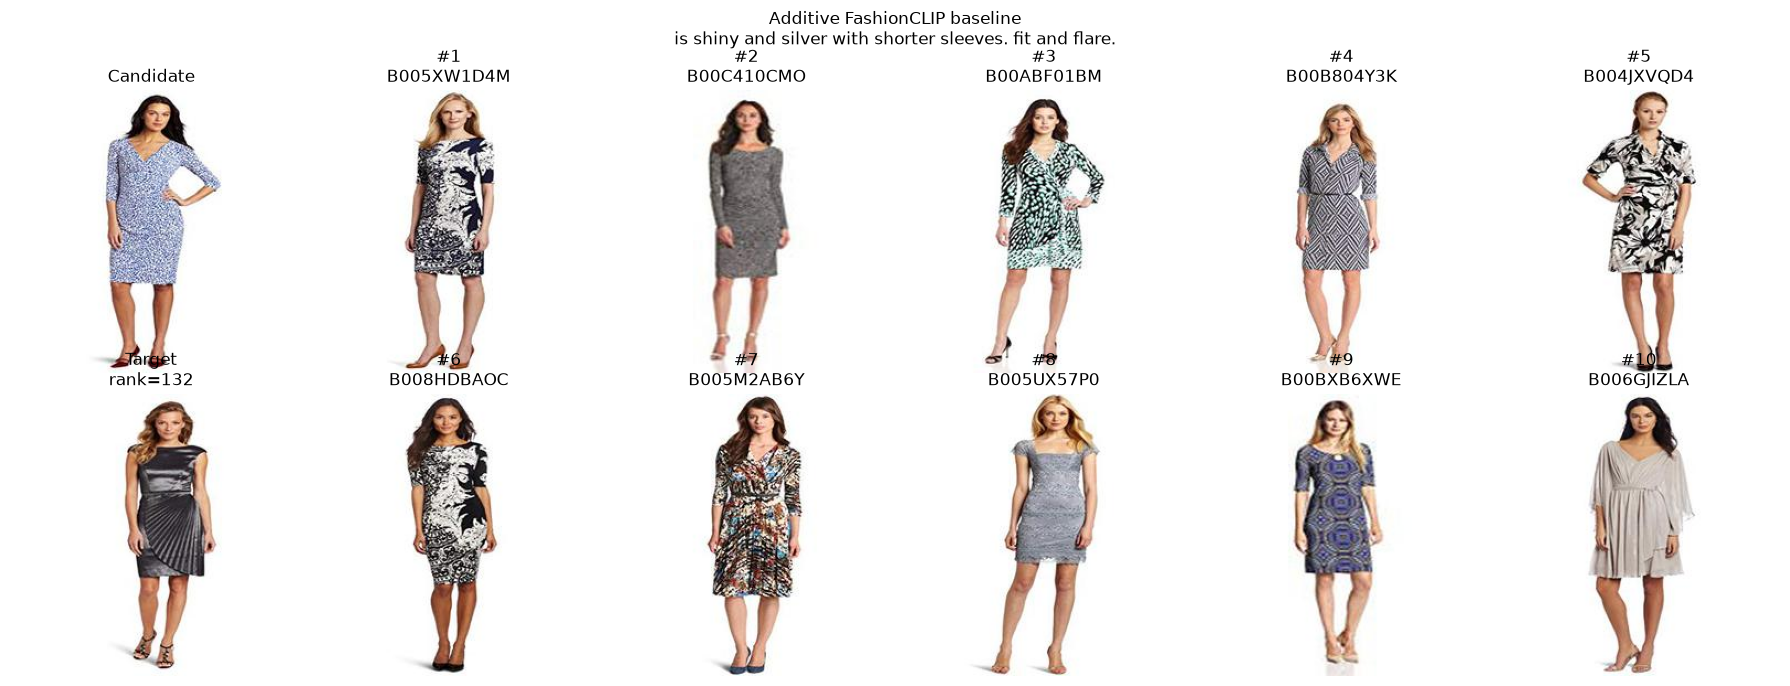

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

category = "dress"

sample = eval_queries[
    eval_queries["eval_category"].eq(category)
].iloc[[0]].copy()

query_vec, _ = build_additive_queries(sample)

gallery_ids = gallery_ids_by_category[category]
gallery_rows = gallery_rows_by_category[category]
gallery_emb = np.asarray(
    image_embeddings[gallery_rows],
    dtype=np.float32
)
gallery_emb = l2_normalize(gallery_emb)

scores = (query_vec @ gallery_emb.T)[0]

candidate_id = str(sample.iloc[0]["candidate"])
target_id = str(sample.iloc[0]["target"])

gallery_local = {
    image_id: idx
    for idx, image_id in enumerate(gallery_ids)
}

if EXCLUDE_REFERENCE and candidate_id in gallery_local:
    scores[gallery_local[candidate_id]] = -np.inf

top10_idx = np.argsort(-scores)[:10]
top10_ids = [gallery_ids[i] for i in top10_idx]

target_rank = int(
    1 + np.sum(scores > scores[gallery_local[target_id]])
)

print("Candidate ", candidate_id)
print("Target ", target_id)
print("Target rank ", target_rank)
print("Text ", sample.iloc[0]["text"])

def image_path_from_id(image_id):
    row_idx = image_id_to_row[str(image_id)]
    return image_map.iloc[row_idx]["image_path"]

fig, axes = plt.subplots(2, 6, figsize=(18, 7))

# Candidate
candidate_img = Image.open(
    image_path_from_id(candidate_id)
).convert("RGB")
axes[0, 0].imshow(candidate_img)
axes[0, 0].set_title("Candidate")
axes[0, 0].axis("off")

# Target
target_img = Image.open(
    image_path_from_id(target_id)
).convert("RGB")
axes[1, 0].imshow(target_img)
axes[1, 0].set_title(f"Target\nrank={target_rank}")
axes[1, 0].axis("off")

# Top-10
for j, (idx, image_id) in enumerate(zip(top10_idx, top10_ids)):
    r = j // 5
    c = (j % 5) + 1

    img = Image.open(
        image_path_from_id(image_id)
    ).convert("RGB")

    axes[r, c].imshow(img)

    label = f"#{j+1}\n{image_id}"
    if image_id == target_id:
        label += "\nTARGET"

    axes[r, c].set_title(label)
    axes[r, c].axis("off")

plt.suptitle(
    "Additive FashionCLIP baseline\n"
    + sample.iloc[0]["text"],
    fontsize=12
)

plt.tight_layout()
plt.show()

## **19 - PHÂN TÍCH NHANH TARGET RANK**

Cell này không thay đổi Recall@K mà chỉ giúp hiểu chất lượng ranking.

Các thống kê bao gồm:
- Median rank: vị trí target trung vị.
- Mean rank: vị trí target trung bình.
- Best/Worst rank: query tốt nhất và kém nhất.


In [17]:
rank_analysis = (
    per_query_results
    .groupby("category")["target_rank"]
    .agg(
        queries="count",
        mean_rank="mean",
        median_rank="median",
        best_rank="min",
        worst_rank="max",
    )
    .reset_index()
)

display(rank_analysis)

,category,queries,mean_rank,median_rank,best_rank,worst_rank
0,dress,2017,417.513634,86.0,1,3802
1,shirt,2038,666.562316,137.5,1,6341
2,toptee,1961,480.546660,73.0,1,5289


## **20 - LƯU CẤU HÌNH GIAO THỨC ĐÁNH GIÁ**

Bước cuối cùng là lưu lại toàn bộ quy tắc đánh giá (protocol). Việc này bắt buộc phải làm để đảm bảo tính công bằng khi so sánh các mô hình với nhau. Chỉ số Recall@K chỉ có ý nghĩa khi tất cả đều được đo lường chung trên một hệ quy chiếu: cùng tập validation, cùng gallery, cùng cách tạo query, cùng cách lọc candidate và cùng hệ số K.


In [18]:
import json
import datetime

run_config = {
    "date_local": datetime.datetime.now().isoformat(),
    "data_root": str(DATA_ROOT),
    "week37_embedding_root": str(WEEK37_EMB_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "evaluation_split": EVAL_SPLIT,
    "categories": CATEGORIES,
    "query_fusion": "L2_normalize(image_embedding + text_embedding)",
    "similarity": "dot product on L2-normalized vectors = cosine similarity",
    "top_ks": TOP_KS,
    "query_batch_size": QUERY_BATCH_SIZE,
    "exclude_reference_image": EXCLUDE_REFERENCE,
    "text_sources": [
        f"cap.{c}.{EVAL_SPLIT}.json"
        for c in CATEGORIES
    ],
    "gallery_sources": [
        f"split.{c}.{EVAL_SPLIT}.json"
        for c in CATEGORIES
    ],
    "num_eval_queries": int(len(eval_queries)),
    "num_image_embeddings": int(image_embeddings.shape[0]),
    "embedding_dim": int(image_embeddings.shape[1]),
}

config_file = OUTPUT_ROOT / "evaluation_protocol.json"

with open(config_file, "w", encoding="utf-8") as f:
    json.dump(
        run_config,
        f,
        ensure_ascii=False,
        indent=2
    )

print(json.dumps(
    run_config,
    ensure_ascii=False,
    indent=2
))

print("\nSaved", config_file)

{
  "date_local": "2026-09-21T10:32:35.732279",
  "data_root": "C:\\Users\\Nguyen Ho Vinh  Hien\\Downloads\\FashionIQ\\fashionIQ_dataset",
  "week37_embedding_root": "C:\\Users\\Nguyen Ho Vinh  Hien\\Downloads\\KHOALUAN\\Week37\\embeddings",
  "output_root": "C:\\Users\\Nguyen Ho Vinh  Hien\\Downloads\\KHOALUAN\\Week38\\evaluation",
  "evaluation_split": "val",
  "categories": [
    "dress",
    "shirt",
    "toptee"
  ],
  "query_fusion": "L2_normalize(image_embedding + text_embedding)",
  "similarity": "dot product on L2-normalized vectors = cosine similarity",
  "top_ks": [
    10,
    50
  ],
  "query_batch_size": 128,
  "exclude_reference_image": true,
  "text_sources": [
    "cap.dress.val.json",
    "cap.shirt.val.json",
    "cap.toptee.val.json"
  ],
  "gallery_sources": [
    "split.dress.val.json",
    "split.shirt.val.json",
    "split.toptee.val.json"
  ],
  "num_eval_queries": 6016,
  "num_image_embeddings": 74381,
  "embedding_dim": 512
}

Saved C:\Users\Nguyen Ho Vinh  H

## **21 - KẾT LUẬN NOTEBOOK**

Pipeline:

```text
FashionCLIP image embedding tuần 37
        +
FashionCLIP text embedding tuần 37
        ↓
Additive composed query
        ↓
Category-specific validation gallery
        ↓
Cosine similarity
        ↓
Target ranking
        ↓
Recall@10 và Recall@50
```

Các file cần giữ lại:

```text
evaluation/
├── recall_summary.csv
├── recall_per_query.csv
└── evaluation_protocol.json
```

Kết quả quan trọng nhất để đưa vào báo cáo là bảng Recall@10 và Recall@50 của:
- Dress
- Shirt
- Toptee
- Macro Average
- Micro Overall
